In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = "Malgun Gothic"
matplotlib.rcParams['axes.unicode_minus'] = False


In [4]:
df = pd.read_csv('https://www.football-data.co.uk/mmz4281/2526/F1.csv')
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,F1,15/08/2025,19:45,Rennes,Marseille,1,0,H,0,0,...,1.95,1.90,1.94,1.98,1.95,1.97,1.86,1.89,1.97,2.02
1,F1,16/08/2025,16:00,Lens,Lyon,0,1,A,0,1,...,1.80,2.05,1.76,2.18,1.82,2.10,1.77,2.02,1.86,2.15
2,F1,16/08/2025,18:00,Monaco,Le Havre,3,1,H,1,0,...,2.00,1.85,2.10,1.79,2.05,1.85,1.96,1.77,2.07,1.88
3,F1,16/08/2025,20:05,Nice,Toulouse,0,1,A,0,0,...,1.98,1.88,2.14,1.78,1.98,1.93,1.93,1.83,2.06,1.92
4,F1,17/08/2025,14:00,Brest,Lille,3,3,D,1,2,...,2.10,1.78,2.29,1.68,2.12,1.78,2.02,1.70,2.22,1.79


In [5]:
# 일단 팀이 몇개 있는지 확인
all_teams = pd.concat([df['HomeTeam'],df['AwayTeam']]).unique()
print(all_teams)

['Rennes' 'Lens' 'Monaco' 'Nice' 'Brest' 'Angers' 'Auxerre' 'Metz'
 'Nantes' 'Paris SG' 'Marseille' 'Lyon' 'Lorient' 'Le Havre' 'Strasbourg'
 'Toulouse' 'Lille' 'Paris FC']


In [ ]:
# 현재 기준(2026-01-10) Ligue1의 1위는 Lens 입니다.
# Lens의 홈에서의 슈팅효율, 원정에서의 슈팅효율을 구하자
# 일단 먼저 Lens의 정보만 뽑아오는 과정

# df_teams로 2위팀 Paris SG, 꼴찌팀인 Metz
df_teams = df[['HomeTeam','AwayTeam','FTHG','FTAG','FTR','HS','AS','HST','AST']] # 홈, 원정, 홈 득점, 원정 득점, 승무패, 홈 슈팅, 원정 슈팅, 홈 유효슈팅, 원정 유효슈팅

Lens_home = df_teams[df_teams['HomeTeam'] == 'Lens']
Lens_away = df_teams[df_teams['AwayTeam'] == 'Lens']

PSG_home = df_teams[df_teams['HomeTeam'] == 'Paris SG']
PSG_away = df_teams[df_teams['AwayTeam'] == 'Paris SG']

Metz_home = df_teams[df_teams['HomeTeam'] == 'Metz']
Metz_away = df_teams[df_teams['AwayTeam'] == 'Metz']

# lens, psg, metz 로 나눠서 보여주도록 설정
print('Lens Home & Away')
print(Lens_home) # lens 홈 성적
print(Lens_away) # lens 원정 성적
print('------------------------------')
print('PSG Home & Away')
print(PSG_home) # PSG 홈 성적
print(PSG_away) # PSG 원정 성적
print('------------------------------')
print('Metz Home & Away')
print(Metz_home) # Metz 홈 성적
print(Metz_away) # Metz 원정 성적
print('------------------------------')


Lens Home & Away
    HomeTeam    AwayTeam  FTHG  FTAG FTR  HS  AS  HST  AST
1       Lens        Lyon     0     1   A  18  11    5    3
18      Lens       Brest     3     1   H  30   9   10    2
39      Lens       Lille     3     0   H  15  17    6    3
67      Lens    Paris FC     2     1   H  11   9    3    3
75      Lens   Marseille     2     1   H   8  17    5    3
94      Lens     Lorient     3     0   H   9  12    6    3
109     Lens  Strasbourg     1     0   H  13   7    5    1
141     Lens        Nice     2     0   H  15   8    5    4
     HomeTeam AwayTeam  FTHG  FTAG FTR  HS  AS  HST  AST
14   Le Havre     Lens     1     2   A  18   6    6    3
33   Paris SG     Lens     2     0   H  14  11    6    3
53     Rennes     Lens     0     0   D  14  13    2    2
57    Auxerre     Lens     1     2   A  18   7    2    4
83       Metz     Lens     2     0   H  16  10    7    2
102    Monaco     Lens     1     4   A  16  20    6   12
122    Angers     Lens     1     2   A   7  17    5  

In [34]:
# 데이터 집계 (Home + Away 합산 기준)
# RC Lens 데이터 집계
Lens_total_shots = Lens_home['HS'].sum() + Lens_away['AS'].sum() # Home + Away 슈팅 합산
Lens_total_shots_target = Lens_home['HST'].sum() + Lens_away['AST'].sum() # Home + Away 유효슈팅 합산
Lens_total_goals = Lens_home['FTHG'].sum() + Lens_away['FTAG'].sum() # Home + Away 전체 합산 골
# PSG 데이터 집계
PSG_total_shots = PSG_home['HS'].sum() + PSG_away['AS'].sum()
PSG_total_shots_target = PSG_home['HST'].sum() + PSG_away['AST'].sum()
PSG_total_goals = PSG_home['FTHG'].sum() + PSG_away['FTAG'].sum()
# Metz 데이터 집계
Metz_total_shots = Metz_home['HS'].sum() + Metz_away['AS'].sum()
Metz_total_shots_target = Metz_home['HST'].sum() + Metz_away['AST'].sum()
Metz_total_goals = Metz_home['FTHG'].sum() + Metz_away['FTAG'].sum()

# 1. 전체 슈팅 중 유효슈팅 비율
# RC Lens
Lens_shots_acc = (Lens_total_shots_target / Lens_total_shots) * 100
# PSG
PSG_shots_acc = (PSG_total_shots_target / PSG_total_shots) * 100
# Metz
Metz_shots_acc = (Metz_total_shots_target / Metz_total_shots) * 100

# 2. 유효 슈팅 대비 득점 비율
# RC Lens
Lens_shots_target_eff = (Lens_total_goals / Lens_total_shots_target) * 100
# PSG
PSG_shots_target_eff = (PSG_total_goals / PSG_total_shots_target) * 100
# Metz
Metz_shots_target_eff = (Metz_total_goals / Metz_total_shots_target) * 100
# 3. 전체 슈팅 대비 득점 비율
# RC Lens
Lens_shots_total_eff = (Lens_total_goals / Lens_total_shots) * 100
# PSG
PSG_shots_total_eff = (PSG_total_goals / PSG_total_shots) * 100
# Metz
Metz_shots_total_eff = (Metz_total_goals / Metz_total_shots) * 100

print(f'RC Lens 전체 슈팅 : {Lens_total_shots}')
print(f'RC Lens 유효 슈팅 : {Lens_total_shots_target}')
print(f'RC Lens 전체 골 : {Lens_total_goals}')
print(f'RC Lens 전체 슈팅 중 유효슈팅 비율 : {Lens_shots_acc:.2f}%')
print(f'RC Lens 유효 슈팅 대비 득점 비율 : {Lens_shots_target_eff:.2f}%')
print(f'RC Lens 전체 슈팅 대비 득점 비율 : {Lens_shots_total_eff:.2f}%')
print('-----------------------------')
print(f'PSG 전체 슈팅 : {PSG_total_shots}')
print(f'PSG 유효 슈팅 : {PSG_total_shots_target}')
print(f'PSG 전체 골 : {PSG_total_goals}')
print(f'PSG 전체 슈팅 중 유효슈팅 비율 : {PSG_shots_acc:.2f}%')
print(f'PSG 유효 슈팅 대비 득점 비율 : {PSG_shots_target_eff:.2f}%')
print(f'PSG 전체 슈팅 대비 득점 비율 : {PSG_shots_total_eff:.2f}%')
print('-----------------------------')
print(f'Metz 전체 슈팅 : {Metz_total_shots}')
print(f'Metz 유효 슈팅 : {Metz_total_shots_target}')
print(f'Metz 전체 골 : {Metz_total_goals}')
print(f'Metz 전체 슈팅 중 유효슈팅 비율 : {Metz_shots_acc:.2f}%')
print(f'Metz 유효 슈팅 대비 득점 비율 : {Metz_shots_target_eff:.2f}%')
print(f'Metz 전체 슈팅 대비 득점 비율 : {Metz_shots_total_eff:.2f}%')
print('-----------------------------')




RC Lens 전체 슈팅 : 239
RC Lens 유효 슈팅 : 90
RC Lens 전체 골 : 31
RC Lens 전체 슈팅 중 유효슈팅 비율 : 37.66%
RC Lens 유효 슈팅 대비 득점 비율 : 34.44%
RC Lens 전체 슈팅 대비 득점 비율 : 12.97%
-----------------------------
PSG 전체 슈팅 : 303
PSG 유효 슈팅 : 116
PSG 전체 골 : 37
PSG 전체 슈팅 중 유효슈팅 비율 : 38.28%
PSG 유효 슈팅 대비 득점 비율 : 31.90%
PSG 전체 슈팅 대비 득점 비율 : 12.21%
-----------------------------
Metz 전체 슈팅 : 151
Metz 유효 슈팅 : 53
Metz 전체 골 : 18
Metz 전체 슈팅 중 유효슈팅 비율 : 35.10%
Metz 유효 슈팅 대비 득점 비율 : 33.96%
Metz 전체 슈팅 대비 득점 비율 : 11.92%
-----------------------------


In [37]:
# 시각화용 데이터프레임
# RC Lens
df_lens = pd.DataFrame({
  'Team' : 'RC Lens',
  'Metric' : ['Shot Accuracy', 'Finish Effect', 'Goal Effect'],
  'Value (%)' : [Lens_shots_acc, Lens_shots_target_eff, Lens_shots_total_eff]
})
# PSG
df_psg = pd.DataFrame({
  'Team' : 'Paris SG',
  'Metric' : ['Shot Accuracy', 'Finish Effect', 'Goal Effect'],
  'Value (%)' : [PSG_shots_acc, PSG_shots_target_eff, PSG_shots_total_eff]
})
# Metz
df_metz = pd.DataFrame({
  'Team' : 'Metz',
  'Metric' : ['Shot Accuracy', 'Finish Effect', 'Goal Effect'],
  'Value (%)' : [Metz_shots_acc, Metz_shots_target_eff, Metz_shots_total_eff]
})
# 세 팀의 지표를 하나로 합치기
df_compare = pd.concat([df_lens, df_psg, df_metz], ignore_index=True)


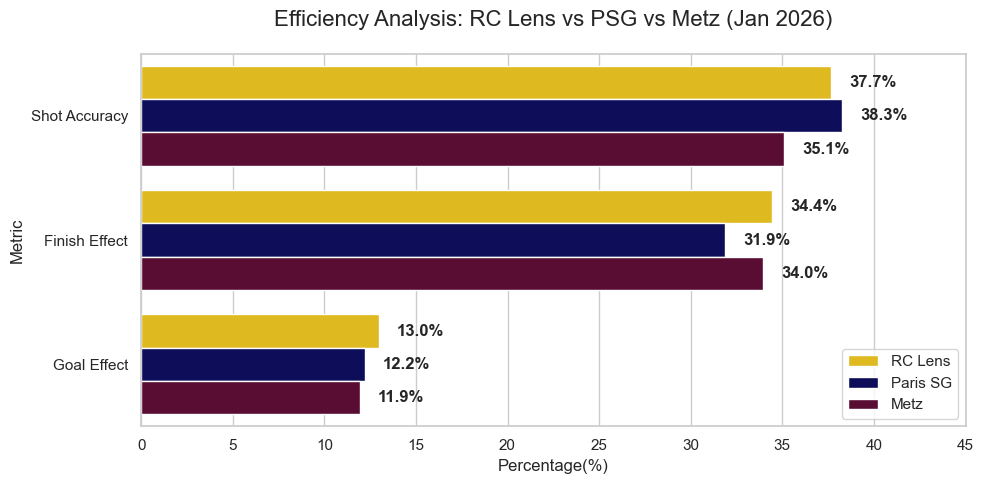

In [56]:
# 그래프 스타일
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,5))

# 랑스를 상징하는 색으로 그래프색 표현
lens_colors = ['#FFCC00', '#FF6600', '#CC0000']
# 이제는 세팀을 비교하는거기 때문에 각 팀의 대표색으로 표현
teams_colors = ['#FFCC00','#000066','#660033']

# 가로형 바 그래프 생성(가독성이 좋을것같아서)

ax = sns.barplot(
  data=df_compare, 
  x='Value (%)', 
  y='Metric', 
  hue='Team', # 색상을 구분할 기준
  palette=teams_colors, 
  legend=True
  )

# 수치 표시
for p in ax.patches: # p는 각 막대(객체)를 의미
  # width : 막대의 가로 길이(Value(%)값)를 가져옴
  width = p.get_width()
  if width > 0: # 0보다 큰 값일 때만 텍스트를 그립니다
    # plt.text(x좌표, y좌표, 표시할 내용, 옵션)
    plt.text(
      width + 1, # 막대 끝에서 1만큼 오른쪽 여백
      p.get_y() + p.get_height()/2, # 막대의 세로 위치(y)에서 높이의 절반을 더해 '중앙에 맞춤
      f'{width:.1f}%', # width 값을 소수점 첫째 자리까지 문자열로 포맷팅
      va='center',  # 수직 정렬을 중앙으로 설정
      fontweight='bold' # 글씨는 굵게
    )


# 타이틀을 포함 마무리 
plt.title("Efficiency Analysis: RC Lens vs PSG vs Metz (Jan 2026)",fontsize=16, pad=20)
plt.xlabel('Percentage(%)')
plt.xlim(0, 45) # 수치 표시 공간 확보
plt.tight_layout()

plt.legend()
plt.show()